In [1]:
%matplotlib inline
import matplotlib.pylab as plt

from matplotlib import rc, animation, patches
rc('animation', html='html5')

import numpy as np
import scipy.integrate as integrate

from scipy.linalg import solve_continuous_are

In [2]:
def wrap_to_pi(angle):
    return (angle + np.pi) % (2 * np.pi) - np.pi

def find_nearest_upright(theta):
    return np.pi * (2 * round((theta - np.pi) / (2 * np.pi)) + 1)

In [32]:
#### AI Gym batched cartpole data generation

import matplotlib.pylab as plt
from matplotlib import rc, animation, patches
rc('animation', html='html5')
import numpy as np
import scipy.integrate as integrate
from scipy.linalg import solve_continuous_are

import torch
import numpy as np
from scipy.linalg import solve_continuous_are

# def find_nearest_upright(theta):
#     # return np.pi * (2 * torch.round((theta - np.pi) / (2 * np.pi)) + 1)
#     return torch.pi * (2 * torch.round((theta - torch.pi) / (2 * torch.pi)) + 1)

def find_nearest_upright(theta):
    """
    theta: (B,) tensor of angles
    return: (B,) tensor of upright points nearest to each theta
    """
    upright_angles = torch.pi * 2 * torch.round((theta) / (2 * torch.pi))
    # zeros = torch.zeros_like(upright_angles)
    # upright_points = torch.stack([zeros, upright_angles, zeros, zeros], dim=1)  # shape (B, 4)
    # print(f"upright_points shape: {upright_points.shape}")
    # return upright_points
    # print(f"upright angles: {upright_angles}")
    return upright_angles


def make_batched_controller(m_c, m_1, l_1, device='cuda:0'):
    """
    Create a batched controller function for the cartpole system,
    where m_c, m_1, l_1 are tensors of shape (batch_size,) on device.
    """
    g = 9.81

    batch_size = m_c.shape[0]

    # Compute LQR gains for each trajectory batch individually using scipy (CPU)
    # We'll do this in a loop because scipy does not support batch.
    # Then transfer to device as tensor batch.
    K_lqr_batch = []
    for i in range(batch_size):
        total_mass = m_1[i].item() + m_c[i].item()
        cartmass = m_c[i].item()
        polemass = m_1[i].item()
        polelength = l_1[i].item()

        alpha = polelength * (4 * polemass + cartmass) / (3 * total_mass)

        a23 = - (g * polemass * polelength) / (total_mass * alpha)
        a43 = g / alpha

        b2 = (1/total_mass) + (polemass * polelength) / (total_mass**2 * alpha)
        b4 = - 1 / (total_mass * alpha)

        A_eq = np.array([
            [0, 1, 0, 0],
            [0, 0, a23, 0],
            [0, 0, 0, 1],
            [0, 0, a43, 0]
        ])

        B_eq = np.array([
            [0],
            [b2],
            [0],
            [b4]
        ])



        # A_eq = np.array([
        #     [0, 0, 1, 0],
        #     [0, 0, 0, 1],
        #     [0, g*m_1[i].item()/m_c[i].item(), 0, 0],
        #     [0, g*(m_1[i].item()+m_c[i].item())/(l_1[i].item()*m_c[i].item()), 0, 0]
        # ])
        # B_eq = np.array([
        #     0,
        #     0,
        #     1/m_c[i].item(),
        #     1/(l_1[i].item()*m_c[i].item())
        # ]).reshape(-1,1)
        # Q = np.eye(4)
        Q = np.diag([10, 1, 10, 1])
        R = np.eye(1)
        X_are = solve_continuous_are(A_eq, B_eq, Q, R)
        K_lqr = np.linalg.inv(R) @ B_eq.T @ X_are
        K_lqr_batch.append(K_lqr[0])  # shape (4,)
    K_lqr = torch.tensor(np.stack(K_lqr_batch), dtype=torch.float32, device=device)  # (batch_size, 4)
    # print(f"K_lqr: {K_lqr}")

    # eq_point = torch.tensor([0, np.pi, 0, 0], dtype=torch.float32, device=device).unsqueeze(0).repeat(batch_size, 1)
    # eq_point_sym = torch.tensor([0, -np.pi, 0, 0], dtype=torch.float32, device=device).unsqueeze(0).repeat(batch_size, 1)

    # def f_lin_feedback(state, use_sym):
    # def f_lin_feedback(state):
    def f_lin_feedback(state, eq_point):
        """
        Batched linear feedback control, state shape: (batch, 4)
        use_sym: boolean mask tensor of shape (batch,) deciding which equilibrium
        """
        # eq_pts = torch.where(use_sym.unsqueeze(-1), eq_point_sym, eq_point)
        # eq_theta = find_nearest_upright(state[:, 2])
        # eq_pts = torch.stack([torch.zeros_like(eq_theta), torch.zeros_like(eq_theta), eq_theta, torch.zeros_like(eq_theta)], dim=1)

        # diff = state - eq_pts
        diff = state - eq_point
        # Elementwise multiply and sum along last dim
        # u = -(K_lqr * diff).sum(dim=1)
        # print(f"eq_pts: {eq_pts.shape}, K_lqr: {K_lqr.shape}")
        u = -(K_lqr * diff).sum(dim=1)
        # print(f"f_lin_feedback: {u.shape}")
        return u

    def controller(state, t, args):
        """
        state: (batch, 4)
        args: tuple of two tensors (switched: bool batch, use_sym: bool batch)
        returns:
          - control force u: (batch,)
          - updated args (switched, use_sym)
        """
        switched, use_sym = args
        # x, theta1, x_dot, theta1_dot = state[:,0], state[:,1], state[:,2], state[:,3]
        x, x_dot, theta1, theta1_dot = state[:, 0], state[:, 1], state[:, 2], state[:, 3]

        # dist_eq_point = torch.norm(state[:,1:] - eq_point[:,1:], dim=1)
        # dist_eq_point_sym = torch.norm(state[:,1:] - eq_point_sym[:,1:], dim=1)
        eq_theta = find_nearest_upright(theta1)
        eq_point = torch.stack([torch.zeros_like(eq_theta), torch.zeros_like(eq_theta), eq_theta, torch.zeros_like(eq_theta)], dim=1)

        not_switched = ~switched
        # switch_to_true = not_switched & ((dist_eq_point <= 0.5) | (dist_eq_point_sym <= 0.5))

        # switch_to_true = not_switched & (((torch.abs(state[:, 1] - eq_point[:, 1]) < 0.5) &
        #                                   (torch.abs(state[:, 3] - eq_point[:, 3]) < 0.5)) |
        #                                     ((torch.abs(state[:, 1] - eq_point_sym[:, 1]) < 0.5) &
        #                                     (torch.abs(state[:, 3] - eq_point_sym[:, 3]) < 0.5)))

        switch_to_true = not_switched & (
            ((torch.abs(state[:, 2] - eq_theta) < 0.3) &
             (torch.abs(state[:, 3] - eq_point[:, 3]) < 1)) 
            # ((torch.abs(state[:, 1] - find_nearest_upright(eq_point_sym[:, 1])) < 0.15) &
            #  (torch.abs(state[:, 3] - eq_point_sym[:, 3]) < 0.15))
        )

        switched = switched | switch_to_true
        # use_sym = torch.where(dist_eq_point_sym <= 0.5, torch.ones_like(use_sym), use_sym)

        # u_lqr = f_lin_feedback(state, use_sym)
        # u_lqr = f_lin_feedback(state)
        u_lqr = f_lin_feedback(state, eq_point)

        theta2 = theta1 + np.pi
        cos_theta2 = torch.cos(theta2)
        sin_theta2 = torch.sin(theta2)
        theta2_dot = -theta1_dot

        # Energy-based swing-up parameters (scalar)
        # K_e, K_p, K_d = 0.2, 0.8, 1.0
        # K_e, K_p, K_d = 0.3, 1.0, 1.0
        K_e, K_p, K_d = 1.0, 1.0, 1.0 # ebonye 2/19/2026

        # Compute Etilde using per-trajectory parameters with broadcasting
        # print(f"m_1 device: {m_1.device}, l_1 device: {l_1.device}, g device: {torch.tensor(g).device}")
        # print(f"theta1 device: {theta1.device}, theta1_dot device: {theta1_dot.device}")
        # global m_1, l_1, g, m_c
        # m_1 = m_1.to(theta1.device)
        # l_1 = l_1.to(theta1.device)
        # g = torch.tensor(g, device=theta1.device)
        # m_c = m_c.to(theta1.device)

        
        Etilde = (-g * l_1 * m_1
                  + 0.5 * l_1 * m_1 * (-2 * g * cos_theta2 + l_1 * theta2_dot * theta2_dot))

        xpp_desired = K_e * cos_theta2 * theta2_dot * Etilde - K_p * x - K_d * x_dot

        theta2_pp = -cos_theta2 / l_1 * xpp_desired - g / l_1 * sin_theta2

        f_swingup = (m_1 + m_c) * xpp_desired + cos_theta2 * l_1 * m_1 * theta2_pp - sin_theta2 * l_1 * m_1 * theta2_dot * theta2_dot

        u = torch.where(switched, u_lqr, f_swingup)
        mode = torch.where(switched, torch.ones_like(u), torch.zeros_like(u))

        return u, (switched, use_sym), mode

    return controller

def step(state, u, m_c, m_1, l_1, dt):
    """
    Compute the next state of the cartpole system given the current state and control input.
    
    state: (batch_size, 4) tensor of current state (x, theta1, x_dot, theta1_dot)
    u: (batch_size,) tensor of control input
    m_c: (batch_size,) tensor of mass of the cart
    m_1: (batch_size,) tensor of mass of the pendulum
    l_1: (batch_size,) tensor of length of the pendulum
    dt: time step for the simulation
    """

    def cartpole_dynamics(state, u, m_c, m_1, l_1):
        """
        Compute the next state of the cartpole system given the current state and control input.
        
        state: (batch_size, 4) tensor of current state (x, theta1, x_dot, theta1_dot)
        u: (batch_size,) tensor of control input
        m_c: (batch_size,) tensor of mass of the cart
        m_1: (batch_size,) tensor of mass of the pendulum
        l_1: (batch_size,) tensor of length of the pendulum
        """
        x, x_dot, theta1, theta1_dot = state[:, 0], state[:, 1], state[:, 2], state[:, 3]
        g = 9.81

        cos_theta1 = torch.cos(theta1)
        sin_theta1 = torch.sin(theta1)

        temp = (u + sin_theta1 * l_1 * m_1 * theta1_dot**2) / (m_c + m_1)
        thetaacc = (g * sin_theta1 - cos_theta1 * temp) / (
            l_1 * (4.0/3.0 - m_1 * cos_theta1**2 / (m_c + m_1))
        )
        xacc = temp - m_1 * l_1 * thetaacc * cos_theta1 / (m_c + m_1)

        return torch.stack([x_dot, xacc, theta1_dot, thetaacc], dim=1)
    
    # Compute the next state using the dynamics and rk4
    k1 = cartpole_dynamics(state, u, m_c, m_1, l_1)
    k2 = cartpole_dynamics(state + 0.5 * dt * k1, u, m_c, m_1, l_1)
    k3 = cartpole_dynamics(state + 0.5 * dt * k2, u, m_c, m_1, l_1)
    k4 = cartpole_dynamics(state + dt * k3, u, m_c, m_1, l_1)
    next_state = state + (dt / 6) * (k1 + 2*k2 + 2*k3 + k4)

    return next_state


def simulate_cartpole_batch(m_c, m_1, l_1, y0=None,
                           total_time=14.0, dt=0.025,
                           device='cuda:0'):
    """
    Batched cart-pole simulation with RK4 integration.

    m_c, m_1, l_1: (batch_size,) tensors on device

    Returns:
        t: (num_steps,)
        ys: (num_steps, batch_size, 4)
        controls: (num_steps-1, batch_size)
    """
    batch_size = m_c.shape[0]
    num_steps = int(total_time / dt)
    t = torch.linspace(0, total_time, num_steps, device=device)

    if y0 is None:
        y0 = torch.stack([
            torch.zeros(batch_size, device=device),          # x
            torch.zeros(batch_size, device=device),          # x_dot
            torch.ones(batch_size, device=device) * np.pi,  # theta1
            torch.zeros(batch_size, device=device)           # theta1_dot
        ], dim=1)
    else:
        y0 = y0.to(device)

    ys = torch.zeros((num_steps, batch_size, 4), dtype=torch.float32, device=device)
    ys[0] = y0
    controls = torch.zeros((num_steps - 1, batch_size), dtype=torch.float32, device=device)
    control_modes = torch.zeros((num_steps - 1, batch_size), dtype=torch.float32, device=device)

    # Testing performance if parameters are mixed up for computing the next step
    permuted_idx = torch.randperm(batch_size)
    m_1_mixed = m_1[permuted_idx]
    l_1_mixed = l_1[permuted_idx]
    m_c_mixed = m_c[permuted_idx]

    # Robustness test: choose parameters fixed across batch for controller
    m_1_robust = torch.ones(batch_size, device=device) * 1.5
    l_1_robust = torch.ones(batch_size, device=device) * 1.8
    m_c_robust = torch.ones(batch_size, device=device) * 2.5

    # controller = make_batched_controller(m_c, m_1, l_1, device=device)
    # controller = make_batched_controller(m_c_mixed, m_1_mixed, l_1_mixed, device=device)
    controller = make_batched_controller(m_c_robust, m_1_robust, l_1_robust, device=device)
    # deriv_func = make_deriv_vectorized(controller, m_c, m_1, l_1, device=device)

    switched = torch.zeros(batch_size, dtype=torch.bool, device=device)
    use_sym = torch.zeros(batch_size, dtype=torch.bool, device=device)
    args = (switched, use_sym)

    for i in range(num_steps - 1):
        y_curr = ys[i]
        t_curr = t[i]
        # y_next, u, args, mode = rk4_step(deriv_func, y_curr, t_curr, dt, args)
        # if i < 50:
        #     u = torch.zeros(batch_size, device=device)  # no control for first 50 steps to test open-loop swing-up
        #     mode = torch.zeros_like(u)
        # else:
        u, args, mode = controller(y_curr, t_curr, args)
        
        # control clipping
        u = torch.clamp(u, -15.0, 15.0)
        # u = torch.clamp(u, -30.0, 30.0)
        
        y_next = step(y_curr, u, m_c, m_1, l_1, dt)
        # y_next = step(y_curr, u, m_c_mixed, m_1_mixed, l_1_mixed, dt)

        ## inject small perturbations during lqr stabilization
        switched_mask = args[0]
        # noise = torch.randn_like(y_next) * 0.02  # small noise
        noise = torch.zeros_like(y_next) # no noise for now, can enable later
        y_next[switched_mask] += noise[switched_mask]
        ## end of perturbations
        


        ys[i+1] = y_next
        controls[i] = u
        control_modes[i] = mode

    return t, ys, controls, control_modes

def checking(Y0, total_time, m_c=torch.tensor([1.0]), m_1=torch.tensor([1.0]), l_1=torch.tensor([1.0]), method='rk4', dt=0.025, device='cuda:0'):
    """
    Check the batched cart-pole system simulation with given parameters.
    
    Parameters:
    - Y0: initial state of the system (x, theta1, x_dot, theta1_dot) as a tensor of shape (batch_size, 4)
    - total_time: total simulation time
    - m_c: mass of the cart
    - m_1: mass of the pendulum
    - l_1: length of the pendulum
    - method: integration method ('rk4' or 'odeint')
    - dt: time step for the simulation
    - device: device to run the simulation on ('cpu' or 'cuda')
    """
    if method == 'rk4':
        t, y, control_logger, control_mode_logger = simulate_cartpole_batch(m_c=m_c, m_1=m_1, l_1=l_1, y0=Y0, total_time=total_time, dt=dt, device=device)
        y = y.permute(1, 0, 2)  # (batch_size, num_steps, 4)
        control_logger = control_logger.permute(1, 0)  # (batch_size, num_steps-1)
        control_mode_logger = control_mode_logger.permute(1, 0) # (batch_size, num_steps-1)
    else:
        raise NotImplementedError("Only 'rk4' method is implemented in this example.")

    return t, y, control_logger, control_mode_logger


In [37]:
import os
import pickle
import io
import os

# 1. Define a helper class to force CPU loading
class CPU_Unpickler(pickle.Unpickler):
    def find_class(self, module, name):
        if module == 'torch.storage' and name == '_load_from_bytes':
            return lambda b: torch.load(io.BytesIO(b), map_location='cpu')
        return super().find_class(module, name)

number_of_context = 25
num_pends = 100
# base_dir = f"/data/esmith/Dataset_Cartpole_AIGymWithNoise_ICL_new_ranges_zero_dyn/picklefolder_test_outofdistr"
base_dir = f"/data/esmith/Dataset_Cartpole_AIGymWithNoise_ICL_new_ranges_zero_dyn/picklefolder_test_indistr"
pickle_file = f"batch_test_0_{number_of_context}.pkl"

# torch.serialization.register_last_resort_restore_location(lambda storage, loc: storage.cpu())
file_path_test_data = os.path.join(base_dir, pickle_file)
with open(file_path_test_data, "rb") as f:
        # xs, ys, cartmasses, polemasses, polelenghs = torch.load(f, map_location='cpu', weights_only=False)
        xs, ys, cartmasses, polemasses, polelenghs = CPU_Unpickler(f).load()

pends = np.arange(num_pends)
m_c = [cartmasses[p] for p in pends]
# m_c = torch.stack(m_c).float()
m_c = np.stack(m_c).astype(np.float32)
m_1 = [polemasses[p] for p in pends]
# m_1 = torch.stack(m_1).float()
m_1 = np.stack(m_1).astype(np.float32)
l_1 = [polelenghs[p] for p in pends]
# l_1 = torch.stack(l_1).float()
l_1 = np.stack(l_1).astype(np.float32)
states = [xs[p].cpu().detach().numpy() for p in pends]
init_conds = [states[p][0] for p in pends]
# init_conds = torch.tensor(init_conds, dtype=torch.float32)
Y0 = np.array(init_conds).astype(np.float32)

print(f"m_c shape: {m_c.shape}, m_1 shape: {m_1.shape}, l_1 shape: {l_1.shape}, Y0 shape: {Y0.shape}")
       

m_c shape: (100,), m_1 shape: (100,), l_1 shape: (100,), Y0 shape: (100, 4)


In [38]:
# Example usage
seed = 11 #42
torch.manual_seed(seed)
np.random.seed(seed)
# batch_size = 2000
# theta_init = torch.tensor(np.random.uniform(np.pi-np.pi/2, np.pi+np.pi/2, size=(batch_size, 1)), dtype=torch.float32)
# theta_dot_init = torch.tensor(np.random.uniform(-1.0, 1.0, size=(batch_size, 1)), dtype=torch.float32)
# # theta_init = torch.tensor([2.39, 1.93], dtype=torch.float32).unsqueeze(1)  # Fixed initial angles for testing
# # theta_dot_init = torch.tensor([0.3, 0.68], dtype=torch.float32).unsqueeze(1)  # Fixed initial angular velocities for testing
# Y0 = torch.cat([
#     torch.zeros(batch_size, 1),  # x
#     torch.zeros(batch_size, 1),  # x_dot
#     theta_init,                  # theta1
#     theta_dot_init                # theta1_dot
# ], dim=1)  # shape (batch_size, 4)

# # m_c = torch.ones(batch_size, dtype=torch.float32) * 2.0  # mass of the cart
# # In-distribution (ID)
# # m_1 = torch.tensor(np.random.uniform(0.3, 1.0, size=batch_size), dtype=torch.float32)  # mass of the pendulum
# # l_1 = torch.tensor(np.random.uniform(1.0, 1.5, size=batch_size), dtype=torch.float32)  # length of the pendulum
# # OOD
# # m_1 = torch.tensor(np.random.uniform(1.1, 2.0, size=batch_size), dtype=torch.float32)  # mass of the pendulum
# # l_1 = torch.tensor(np.random.uniform(1.6, 2.1, size=batch_size), dtype=torch.float32)  # length of the pendulum

# #####
# # OOD

# m_c = torch.tensor(np.random.uniform(1.5, 2.0, size=batch_size), dtype=torch.float32)
# # m_c = torch.tensor(np.random.uniform(0.8, 1.4, size=batch_size), dtype=torch.float32)
# m_1 = torch.tensor(np.random.uniform(0.3, 0.8, size=batch_size), dtype=torch.float32)  # mass of the pendulum
# # l_1 = torch.tensor(np.random.uniform(1.6, 2.1, size=batch_size), dtype=torch.float32)  # length of the pendulum
# l_1 = torch.tensor(np.random.uniform(1.0, 1.5, size=batch_size), dtype=torch.float32)  # length of the pendulum

# # In-distribution (ID)
# # m_c = torch.tensor(np.random.uniform(0.8, 1.4, size=batch_size), dtype=torch.float32)
# # m_1 = torch.tensor(np.random.uniform(1.2, 2.0, size=batch_size), dtype=torch.float32)  # mass of the pendulum
# # l_1 = torch.tensor(np.random.uniform(2.2, 3.0, size=batch_size), dtype=torch.float32)  # length of the pendulum
# # # good
# # m_c = torch.tensor(np.random.uniform(2.0, 3.0, size=batch_size), dtype=torch.float32)
# # m_1 = torch.tensor(np.random.uniform(1.1, 2.0, size=batch_size), dtype=torch.float32)  # mass of the pendulum
# # l_1 = torch.tensor(np.random.uniform(1.6, 2.1, size=batch_size), dtype=torch.float32)  # length of the pendulum


# # m_1 = torch.tensor([0.90, 0.83], dtype=torch.float32)
# # l_1 = torch.tensor([1.30, 1.14], dtype=torch.float32)
m_c = torch.tensor(m_c, dtype=torch.float32)
m_1 = torch.tensor(m_1, dtype=torch.float32)
l_1 = torch.tensor(l_1, dtype=torch.float32)
Y0 = torch.tensor(Y0, dtype=torch.float32)
t, y, control_logger, control_mode_logger = checking(
    Y0=Y0, total_time=14.0, m_c=m_c, m_1=m_1, l_1=l_1, method='rk4', dt=0.025, device='cpu'
)
print(f"y shape: {y.shape}")  # (batch_size, num_steps, 4)
print(f"m_c[0:5]: {m_c[:5]}")

# print final states of batch
# print("Final states of the batch:")
# for i in range(batch_size):
#     print(f"Batch {i}: {y[i, -1]}")  # Last state of each batch 
# print(f"control mode logger: {control_mode_logger}")  # (batch_size, num_steps-1)

# print(f"control mode logger: {control_mode_logger[:,-1]}")  # (batch_size, num_steps-1)

y shape: torch.Size([100, 560, 4])
m_c[0:5]: tensor([2.3745, 2.9507, 2.7320, 2.5987, 2.1560])


In [39]:
xs_pend_cos_theta = torch.cos(y[:, :, 2])  # (batch_size, num_steps)
xs_pend_sin_theta = torch.sin(y[:, :, 2])  # (batch_size, num_steps)
xs_pend_updated = torch.cat((y[:, :, :2], xs_pend_cos_theta.unsqueeze(-1), xs_pend_sin_theta.unsqueeze(-1), y[:, :, 3:]), dim=-1)  # (batch_size, num_steps, 5)
print(f"xs_pend_updated shape: {xs_pend_updated.shape}")  # (batch_size, num_steps, 5)

goal_state = torch.tensor([0, 0, 1, 0, 0], dtype=torch.float32)  # (5,)
final_window = xs_pend_updated[:, -40:, :]  # Last 40 time steps
cos_theta_thresh = 0.9
sin_theta_thresh = 0.3
theta_dot_thresh = 1.0

is_upright = (
    (torch.abs(final_window[:, :, 2]) > cos_theta_thresh) &
    (torch.abs(final_window[:, :, 3]) < sin_theta_thresh) &
    (torch.abs(final_window[:, :, 4]) < theta_dot_thresh)
)

mask = is_upright.all(dim=1)  # (batch_size,)
print(f"Number of trajectories that ended upright: {mask.sum().item()} out of {num_pends}")

xs_pend_updated shape: torch.Size([100, 560, 5])
Number of trajectories that ended upright: 78 out of 100


In [ ]:
# # Histogram for stabilization time among trajectories that ended upright
# def find_stabilization_index(states, thresholds):
#     """
#     states: (num_steps, 4) tensor (x, x_dot, theta, theta_dot)
#     thresholds: [x_thresh, theta_thresh, theta_dot_thresh]
#     """
#     # Compute absolute errors relative to goal [0, 0, 0, 0]
#     # Handle theta wrap-around to 0
#     theta_error = torch.abs(torch.remainder(states[:, 2] + torch.pi, 2 * torch.pi) - torch.pi)
#     x_error = torch.abs(states[:, 0])
#     theta_dot_error = torch.abs(states[:, 3])

#     # Check where all conditions are met
#     is_stable = (x_error < thresholds[0]) & \
#                 (theta_error < thresholds[1]) & \
#                 (theta_dot_error < thresholds[2])

#     # Find the first index where system was not stable
#     # Everything after this index is the true stabilized region
#     unstated_indices = torch.where(~is_stable)[0]
#     if len(unstated_indices) == 0:
#         return 0  # Always stable

#     last_unstable_index = unstated_indices[-1].item()

#     # If last unstable index is near the end, consider it never stabilized
#     if last_unstable_index >= states.shape[0] - 10:
#         return None
#     return last_unstable_index + 1  # Stabilization starts after the last unstable index






# # stabilization_times = []
# # dt = 0.025
# # # first_idx_where_stabilized = torch.argmax(is_upright, dim=1)  # (batch_size,) index of first time step where upright
# # for i in range(batch_size):
# #     if mask[i]:  # Only consider trajectories that ended upright
# #         upright_indices = torch.where(is_upright[i])[0]  # Indices where trajectory is upright
# #         if len(upright_indices) > 0:
# #             stabilization_time = upright_indices[0].item() #* dt  # Time of first stabilization
# #             print(f"stabilization_time for trajectory {i}: {stabilization_time:.2f} steps")
# #             stabilization_times.append(stabilization_time)

# # Find stabilization times using the new function
# stabilization_times = []
# stabilization_times_all = []
# thresholds = [1, 0.2, 0.5]
# for i in range(batch_size):
#     # if mask[i]:  # Only consider trajectories that ended upright
#     states = y[i]  # (num_steps, 4)
#     stabilization_index = find_stabilization_index(states, thresholds)
#     stabilization_times_all.append(stabilization_index)
#     if stabilization_index is not None:
#         stabilization_time = stabilization_index # * dt
#         # print(f"stabilization_time for trajectory {i}: {stabilization_time:.2f} seconds")
#         stabilization_times.append(stabilization_time)

# print(f"length of stabilization times: {len(stabilization_times)}")
# print(f"Median stabilization time (in steps): {np.median(stabilization_times):.2f}")
# print(f"Mean stabilization time (in steps): {np.mean(stabilization_times):.2f}")
# plt.hist(stabilization_times, bins=75, edgecolor='black')
# plt.title('Histogram of Stabilization Times for Upright Trajectories')
# plt.xlabel('Stabilization Time (s)')
# plt.ylabel('Number of Trajectories')
# plt.grid()
# plt.show()

IndexError: index 100 is out of bounds for dimension 0 with size 100

In [39]:
# 3D scatter plot of cartmass, pendulum mass, pendulum length colored by stabilization pass or fail
from mpl_toolkits.mplot3d import Axes3D
import plotly.graph_objects as go

def plot_3d_stability(m_c, m_1, l_1, settling_indices):
    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111, projection='3d')

    # Success vs failure masks
    success_mask = [i is not None for i in settling_indices]
    failure_mask = [i is None for i in settling_indices]
    print(f"length of success_mask: {len(success_mask)}, length of failure_mask: {len(failure_mask)}")

    # Plot successful stabilizations
    print(f"m_c[success_mask] length: {len(m_c[success_mask])}, m_1[success_mask] length: {len(m_1[success_mask])}, l_1[success_mask] length: {len(l_1[success_mask])}")
    ax.scatter(m_c[success_mask].cpu(), m_1[success_mask].cpu(), l_1[success_mask].cpu(),
                c='green', marker='o', alpha=0.6, label='Stabilized')
    # Plot failures
    ax.scatter(m_c[failure_mask].cpu(), m_1[failure_mask].cpu(), l_1[failure_mask].cpu(),
                c='red', marker='x', alpha=0.4, label='Failed')

    ax.set_xlabel('Cart Mass (kg)')
    ax.set_ylabel('Pendulum Mass (kg)')
    ax.set_zlabel('Pendulum Length (m)')
    ax.set_title('Stability of Cart-Pole System by Parameters')
    ax.legend()
    plt.show()

def plot_interactive_3d(m_c, m_1, l_1, settling_indices):
    success_mask = [i is not None for i in settling_indices]
    failure_mask = [i is None for i in settling_indices]
    colors = ['green' if s else 'red' if s is not None else 'red' for s in success_mask]
    status = ['Stabilized' if s else 'Failed' for s in success_mask]

    fig = go.Figure(data=[go.Scatter3d(
        x=m_c.cpu(),
        y=m_1.cpu(),
        z=l_1.cpu(),
        mode='markers',
        marker=dict(
            size=4,
            color=colors,  # Set color based on stability
            opacity=0.6
        ),
        text=status,  # Hover text
        hoverinfo='text+x+y+z'
    )])
    fig.update_layout(
        title='Stability of Cart-Pole System by Parameters',
        scene=dict(
            xaxis_title='Cart Mass (kg)',
            yaxis_title='Pendulum Mass (kg)',
            zaxis_title='Pendulum Length (m)'
        ),
        margin=dict(l=0, r=0, b=0, t=40)
    )
    fig.show()

# plot_3d_stability(m_c, m_1, l_1, stabilization_times_all)
plot_interactive_3d(m_c, m_1, l_1, stabilization_times_all)

/tmp/ipykernel_4152331/1547020369.py:14: DeprecationWarning:

__array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)

/tmp/ipykernel_4152331/1547020369.py:14: UserWarning:

indexing with dtype torch.uint8 is now deprecated, please use a dtype torch.bool instead. (Triggered internally at /pytorch/aten/src/ATen/native/IndexingUtils.h:29.)

/tmp/ipykernel_4152331/1547020369.py:16: DeprecationWarning:

__array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)

/tmp/ipykernel_4152331/1547020369.py:16: UserWarning:

indexing with dtype torch.uint8 is now deprecated, please use a dtype torch.bool instead. (Triggered internally at /pytorch/aten/src/ATen/native/IndexingUtils.h:29.)



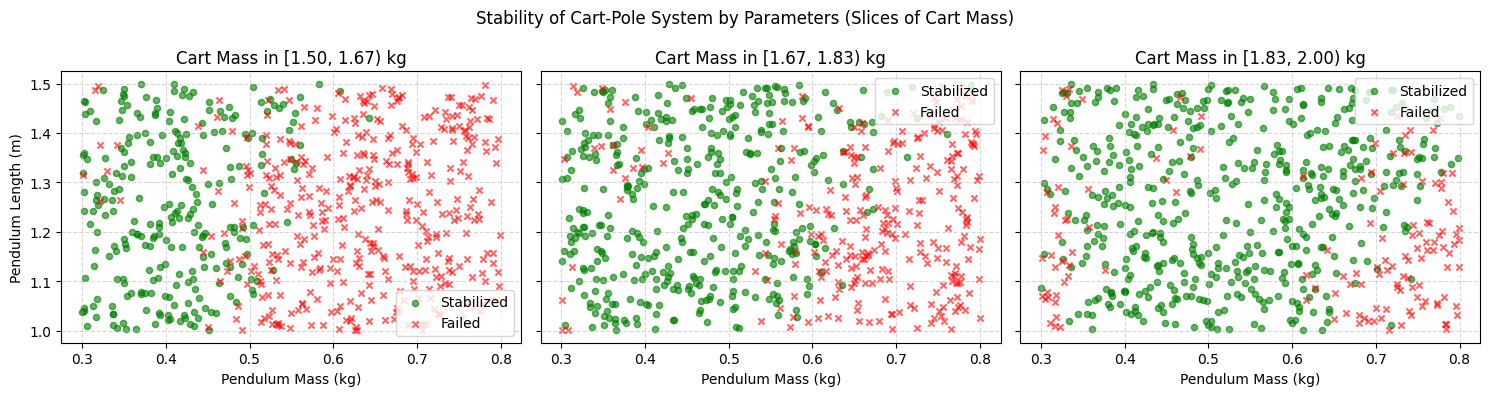

In [40]:
def plot_cartmass_slices(m_c, m_1, l_1, settling_indices, n_slices=4):
    mc_min, mc_max = m_c.min().item(), m_c.max().item()
    bins = np.linspace(mc_min, mc_max, n_slices + 1)

    fig,axes = plt.subplots(1, n_slices, figsize=(5 * n_slices, 4), sharey=True)
    # fig, axes = plt.subplots(1, n_slices, figsize=(6 * n_slices, 5), sharey=True)
    success = np.array([i is not None for i in settling_indices])

    for i in range(n_slices):
        ax = axes[i]
        slice_mask = (m_c >= bins[i]) & (m_c < bins[i+1])
        if slice_mask.sum() == 0:
            continue
        ax.scatter(m_1[slice_mask & success].cpu(), l_1[slice_mask & success].cpu(), 
                    c='green', marker='o', alpha=0.6, s=20, label='Stabilized')
        ax.scatter(m_1[slice_mask & ~success].cpu(), l_1[slice_mask & ~success].cpu(), 
                    c='red', marker='x', alpha=0.6, s=20, label='Failed')
        ax.set_xlabel('Pendulum Mass (kg)')
        ax.set_title(f'Cart Mass in [{bins[i]:.2f}, {bins[i+1]:.2f}) kg')
        if i == 0:
            ax.set_ylabel('Pendulum Length (m)')
        ax.legend()
        ax.grid(True, linestyle='--', alpha=0.5)
    plt.suptitle('Stability of Cart-Pole System by Parameters (Slices of Cart Mass)')
    plt.tight_layout()
    plt.show()


plot_cartmass_slices(m_c, m_1, l_1, stabilization_times_all, n_slices=3)

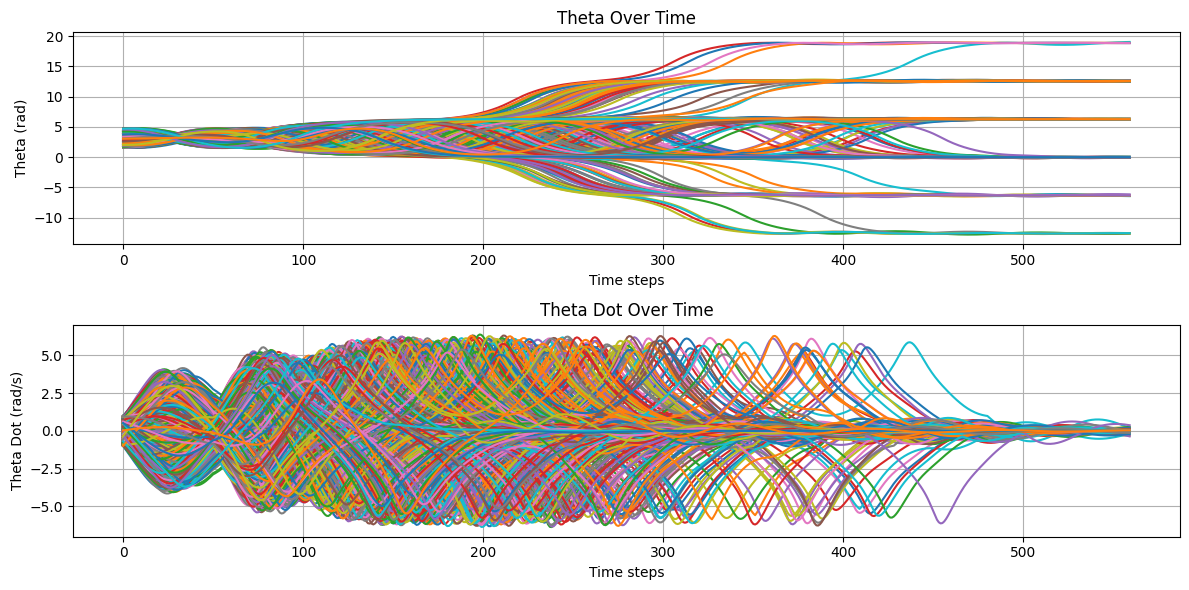

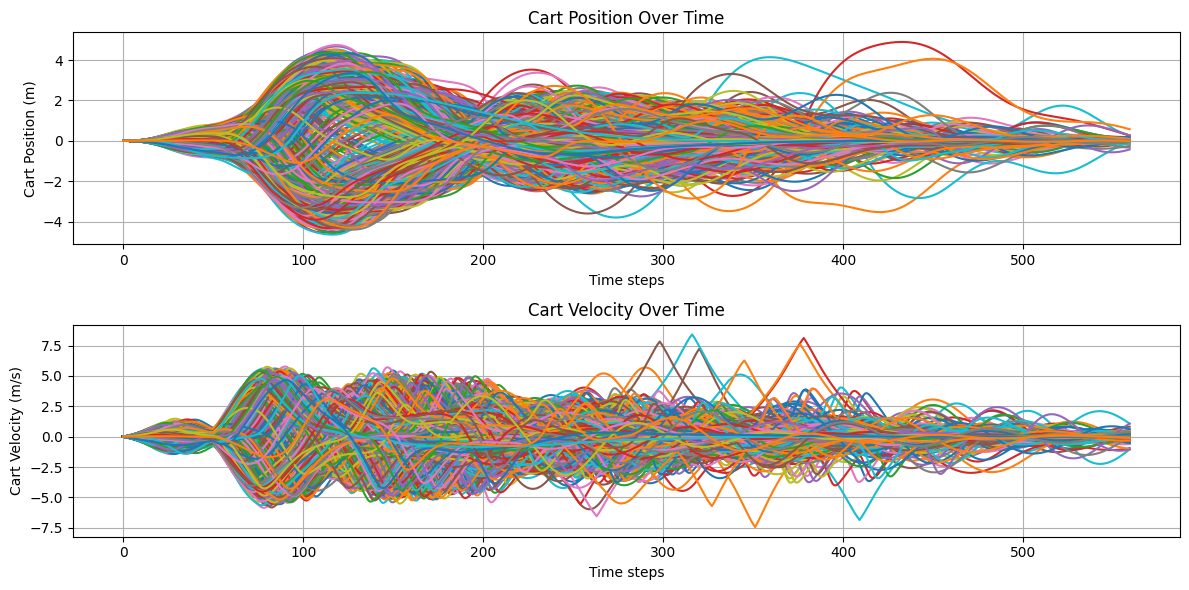

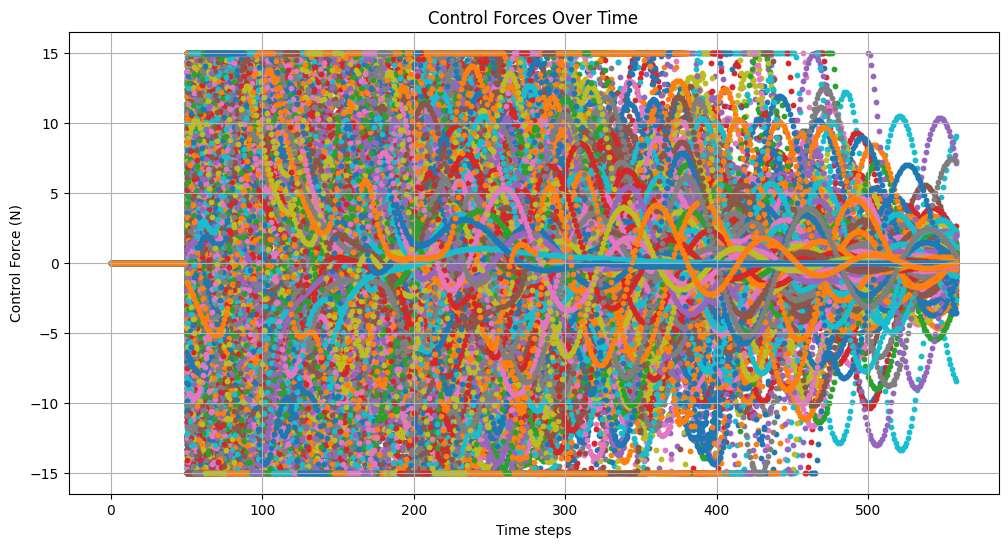

In [ ]:
# # plot theta, theta_dot time series for each in batch on 2 separate plots
# import matplotlib.pyplot as plt
# plt.figure(figsize=(12, 6))
# plt.subplot(2, 1, 1)
# for i in range(batch_size):
#     # plt.plot(t.numpy(), y[i, :, 2].numpy(), label=f'Theta {i+1}')
#     # plt.plot(np.arange(len(y[i, :, 2])), y[i, :, 2].numpy(), label=f'Theta {i+1}')
#     if mask[i]:  # Only plot trajectories that ended upright
#         plt.plot(np.arange(len(y[i, :, 2])), y[i, :, 2].numpy(), label=f'Theta {i+1}')
# plt.title('Theta Over Time')
# # plt.xlabel('Time (s)')
# plt.xlabel('Time steps')  # since we are plotting against index, not actual time
# plt.ylabel('Theta (rad)')
# plt.grid()
# # plt.legend()
# plt.subplot(2, 1, 2)
# for i in range(batch_size):
#     # plt.plot(t.numpy(), y[i, :, 3].numpy(), label=f'Theta Dot {i+1}')
#     # plt.plot(np.arange(len(y[i, :, 3])), y[i, :, 3].numpy(), label=f'Theta Dot {i+1}')
#     if mask[i]:  # Only plot trajectories that ended upright
#         plt.plot(np.arange(len(y[i, :, 3])), y[i, :, 3].numpy(), label=f'Theta Dot {i+1}')
# plt.title('Theta Dot Over Time')
# # plt.xlabel('Time (s)')
# plt.xlabel('Time steps')  # since we are plotting against index, not actual time
# plt.ylabel('Theta Dot (rad/s)')
# plt.grid()
# # plt.legend()
# plt.tight_layout()
# plt.show()

# #Plot x, x_dot time series for each in batch on 2 separate plots
# plt.figure(figsize=(12, 6))
# plt.subplot(2, 1, 1)
# for i in range(batch_size):
#     # plt.plot(t.numpy(), y[i, :, 0].numpy(), label=f'x {i+1}')
#     # plt.plot(np.arange(len(y[i, :, 0])), y[i, :, 0].numpy(), label=f'x {i+1}')
#     if mask[i]:  # Only plot trajectories that ended upright
#         plt.plot(np.arange(len(y[i, :, 0])), y[i, :, 0].numpy(), label=f'x {i+1}')
# plt.title('Cart Position Over Time')
# # plt.xlabel('Time (s)')
# plt.xlabel('Time steps')  # since we are plotting against index, not actual time
# plt.ylabel('Cart Position (m)')
# plt.grid()
# # plt.legend()
# plt.subplot(2, 1, 2)
# for i in range(batch_size):
#     # plt.plot(t.numpy(), y[i, :, 2].numpy(), label=f'x Dot {i+1}')
#     # plt.plot(np.arange(len(y[i, :, 2])), y[i, :, 2].numpy(), label=f'x Dot {i+1}')
#     if mask[i]:  # Only plot trajectories that ended upright
#         plt.plot(np.arange(len(y[i, :, 2])), y[i, :, 1].numpy(), label=f'x Dot {i+1}')
# plt.title('Cart Velocity Over Time')
# # plt.xlabel('Time (s)')
# plt.xlabel('Time steps')  # since we are plotting against index, not actual time
# plt.ylabel('Cart Velocity (m/s)')
# plt.grid()
# # plt.legend()
# plt.tight_layout()
# plt.show()

# #plot control forces for each in batch
# plt.figure(figsize=(12, 6))
# for i in range(batch_size):
#     # plt.scatter(np.arange(len(t[:-1].numpy())), control_logger[i].numpy(), label=f'Control Force {i+1}')
#     if mask[i]:  # Only plot trajectories that ended upright
#         plt.scatter(np.arange(len(control_logger[i])), control_logger[i].numpy(), label=f'Control Force {i+1}', s=10)
# plt.title('Control Forces Over Time')
# plt.xlabel('Time steps')  # since we are plotting against index, not actual time
# plt.ylabel('Control Force (N)')
# plt.grid()
# # plt.legend()
# plt.show()